In [1]:

import os
from dotenv import load_dotenv
load_dotenv()
from typing import List, Dict, Any, Optional,TypedDict,Any
from langgraph.graph import StateGraph, START, END

from langchain_groq import ChatGroq


llm=ChatGroq(model="llama-3.3-70b-versatile")
from langchain_core.messages import HumanMessage

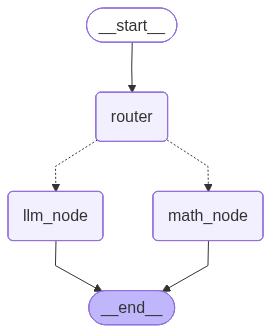

In [19]:
from typing import TypedDict
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

class GraphState(TypedDict):
    question: str
    answer: str

# -------------------------
# 2️⃣ Router Node (just pass state)
# -------------------------
def router_node(state: GraphState) -> GraphState:
    return state

# -------------------------
# 3️⃣ Routing Logic (edge decision)
# -------------------------
def route_decision(state: GraphState) -> str:
    if "calculate" in state["question"].lower():
        return "math_node"
    return "llm_node"

# -----------------------------
# 5️⃣ Math Node
# -----------------------------
def math_node(state: GraphState) -> GraphState:
    expression = state["question"].lower().replace("calculate", "").strip()
    try:
        result = eval(expression)
        return {"answer": f"Result: {result}"}
    except Exception:
        return {"answer": "Invalid math expression"}


# -----------------------------
# 6️⃣ LLM Node
# -----------------------------
def llm_node(state: GraphState) -> GraphState:
    response = llm.invoke([HumanMessage(content=state["question"])])
    return {"answer": response.content}


# -----------------------------
# 7️⃣ Build Graph
# -----------------------------
builder = StateGraph(GraphState)

builder.add_node("router", router_node)
builder.add_node("math_node", math_node)
builder.add_node("llm_node", llm_node)

builder.set_entry_point("router")

builder.add_conditional_edges(
    "router",
    route_decision,
    {
        "math_node": "math_node",
        "llm_node": "llm_node",
    },
)

builder.set_finish_point("math_node")
builder.set_finish_point("llm_node")

graph = builder.compile()

graph

In [21]:
if __name__ == "__main__":
    result = graph.invoke({"question": "what is gen ai in simple 100 line"})
    print(result["answer"])

Here's a simple explanation of Gen AI in 100 words:

Gen AI, or General Artificial Intelligence, refers to a type of AI that can perform any intellectual task a human can. It's a machine that can learn, reason, and apply knowledge like a human. Gen AI can understand language, solve problems, and make decisions autonomously. It's a highly advanced AI that can adapt to new situations and learn from experience, making it potentially more powerful than narrow or specialized AI systems. The goal of Gen AI is to create a machine that can think and act like a human, revolutionizing industries and transforming the way we live and work.


Customer Support  

          User Query
               ↓
          Router Node (LLM Classifier)
               ↓
 ┌─────────────┼──────────────┐
 │             │              │
Order Node   Refund Node   General LLM
 │             │              │
 └─────────────┴──────────────┘
               ↓
              END

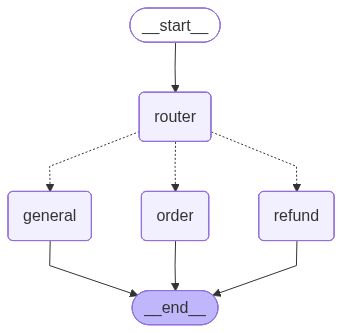

In [35]:
# 1️⃣ Define State
class SupportState(TypedDict):
    query: str
    category: str
    response: str
    
    


# 2️⃣ Router Node (LLM-based classification)
def router_node(state: SupportState):
    query = state["query"].lower()

    if "order" in query:
        return {"category": "order"}
    elif "refund" in query:
        return {"category": "refund"}
    else:
        return {"category": "general"}


# def order_node(state: SupportState):
#     response=llm.invoke([HumanMessage(content=state["query"])])
#     return {"response": response.content}

# 3️⃣ Order Node (Simulating DB lookup)
def order_node(state: SupportState):
    return {"response": "Your order #1234 is shipped and will arrive tomorrow."}

# 4️⃣ Refund Node (Simulating Tool Call)
def refund_node(state: SupportState):
    return {"response": "Refund request created successfully. You will receive money in 5 days."}

# 5️⃣ General LLM Node
def general_node(state: SupportState):
    return {"response": "Thank you for contacting support. How can I assist further?"}

# 6️⃣ Build Graph
builder = StateGraph(SupportState)

builder.add_node("router", router_node)
builder.add_node("order", order_node)
builder.add_node("refund", refund_node)
builder.add_node("general", general_node)

builder.set_entry_point("router")

# Conditional routing logic
def route_decision(state: SupportState):
    return state["category"]

builder.add_conditional_edges(
    "router",
    route_decision,
    {
        "order": "order",
        "refund": "refund",
        "general": "general",
    }
)

builder.add_edge("order", END)
builder.add_edge("refund", END)
builder.add_edge("general", END)

graph = builder.compile()

graph

In [33]:
# Test
result = graph.invoke({"query": "order status for my order bag"})
print(result["response"])

I'm happy to help you with your order status, but I need more information from you. Unfortunately, I'm a large language model, I don't have direct access to your order details or any specific online store's database.

To check the status of your order, could you please provide me with the following details:

1. The name of the online store or retailer where you placed your order.
2. Your order number (if you have it).
3. The date you placed your order.

With this information, I can guide you through the process of checking your order status. Alternatively, you can also try contacting the customer support of the online store directly for assistance.
